# Temporal Reliability Tracker and an Empirical Lyapunov-Style Check, on Real WikiText-2 Token Sequences

STUDY_PLAN.md 3.6 named two of the six gaps this notebook addresses:

- **Item 3**: `notebooks/13_temporal_validation.ipynb` validated `TemporalReliabilityTracker` on real Imagenette images run through a real frozen ResNet-50 at a *constructed* corruption-severity ramp - real model, real images, but an engineered sequence, not organically-occurring data. This notebook is the second, genuinely non-constructed validation: real per-token combiner scores from GPT-2 (124M) run on the real WikiText-2 validation split (`data/llm_feature_cache_gpt2.pt`, produced by `scripts/collect_llm_logits.py`), replayed through the tracker in the real order the tokens occur in real text.
- **Item 4**: a candidate Lyapunov-style function `V(D_t) = (1 - ema_t)^2` built from the tracker's own EMA statistic, and an empirical (not formal) check of whether `E[V(D_{t+1}) | D_t] <= V(D_t)` tends to hold - run against both the corruption-ramp data (item 3's predecessor) and this notebook's real WikiText-2 sequences.

Both are reported honestly, whichever way the numbers land - see `tests/test_temporal.py`'s real-data tests, which this notebook mirrors and which are the actual regression-tested claims; this notebook is the readable, visual companion.


In [1]:
import os
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner
from deployment_reliability.router import auroc
from deployment_reliability.temporal import (
    TemporalReliabilityTracker,
    empirical_lyapunov_transitions,
    lyapunov_candidate,
)


## 1. Load the real GPT-2 / WikiText-2 token cache and fit the combiner

Same protocol as `tests/test_llm_extension.py`: fit `LogisticRegressionCombiner` on `combiner_fit` only, then score every token. Token order *within* a chunk is the real order tokens occur in real WikiText-2 text; chunk boundaries are NOT sequential (each chunk is an independent GPT-2 forward pass - see `test_llm_extension.py`'s `_build_sequence_windows` docstring), so replay below never crosses one.


In [2]:
LLM_CACHE = os.path.join("..", "data", "llm_feature_cache_gpt2.pt")
assert os.path.exists(LLM_CACHE), "run scripts/collect_llm_logits.py first"

CHUNK_SIZE = 1024
TOKENS_PER_CHUNK = CHUNK_SIZE - 1

cache = torch.load(LLM_CACHE)
phi, correct, splits = cache["phi"], cache["correct"], cache["splits"]
splits_arr = np.array(splits)
m_fit = torch.from_numpy(splits_arr == "combiner_fit")

combiner = LogisticRegressionCombiner().fit(phi[m_fit], correct[m_fit].float())
scores = combiner.score(phi)
n_chunks = len(scores) // TOKENS_PER_CHUNK
print(f"total tokens: {len(scores)}  n_chunks: {n_chunks}  overall accuracy: {correct.float().mean().item():.4f}")


total tokens: 257796  n_chunks: 252  overall accuracy: 0.4108


## 2. Item 3: replay real token-order score sequences through the tracker

For a sample of chunks, replay the per-token score stream through `TemporalReliabilityTracker` and record, at each step, whether `is_declining()` fires and the mean correctness of the *next* `k_forward` tokens - the direct analogue of notebook 13's "does a decline signal predict what actually happens next," but on organic text instead of an engineered ramp.


In [3]:
WINDOW = 20
K_FORWARD = 10
N_SAMPLE_CHUNKS = 60

rng = np.random.default_rng(0)
sample_chunks = rng.choice(n_chunks, size=min(N_SAMPLE_CHUNKS, n_chunks), replace=False)

trends, future_correct, one_example_scores = [], [], None
for c in sample_chunks:
    start = int(c) * TOKENS_PER_CHUNK
    chunk_scores = scores[start:start + TOKENS_PER_CHUNK].tolist()
    chunk_correct = correct[start:start + TOKENS_PER_CHUNK].tolist()
    tracker = TemporalReliabilityTracker(window=WINDOW)
    step_trends = []
    for i, s in enumerate(chunk_scores):
        tracker.update(s)
        if i >= 1:
            step_trends.append(tracker.trend())
            future = chunk_correct[i + 1: i + 1 + K_FORWARD]
            if len(future) == K_FORWARD:
                trends.append(tracker.trend())
                future_correct.append(sum(future) / K_FORWARD)
    if one_example_scores is None:
        one_example_scores = (chunk_scores, step_trends)

trends = np.array(trends)
future_correct = np.array(future_correct)
print(f"n replayed transitions: {len(trends)}")


n replayed transitions: 60720


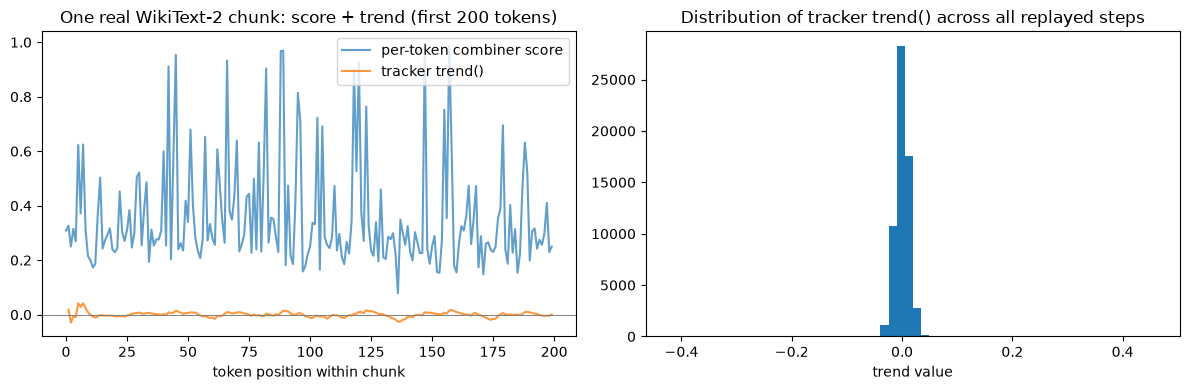

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
example_scores, example_trends = one_example_scores
axes[0].plot(example_scores[:200], label="per-token combiner score", alpha=0.7)
axes[0].plot(range(1, len(example_trends[:199]) + 1), example_trends[:199], label="tracker trend()", alpha=0.8)
axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].set_title("One real WikiText-2 chunk: score + trend (first 200 tokens)")
axes[0].set_xlabel("token position within chunk")
axes[0].legend()

axes[1].hist(trends, bins=60)
axes[1].set_title("Distribution of tracker trend() across all replayed steps")
axes[1].set_xlabel("trend value")
plt.tight_layout()
plt.show()


## 3. Item 3's honest finding: does the trend predict near-future correctness?

Bin by whether the *next* `K_FORWARD` tokens are, on average, more or less than 50% correct, and check whether `trend` at the current step ranks the "will do better next" group above the "will do worse next" group (AUROC) - the same discrimination-quality question this project asks of every other signal.


In [5]:
high = torch.from_numpy(trends[future_correct >= 0.5])
low = torch.from_numpy(trends[future_correct < 0.5])
a = auroc(high, low)
pearson = float(np.corrcoef(trends, future_correct)[0, 1])
print(f"AUROC(trend separates future-high-correctness from future-low-correctness): {a:.4f}")
print(f"Pearson corr(trend, future correctness): {pearson:.4f}")
print()
print("Compare to notebooks/13's corruption-ramp finding: trend-based decline detection was")
print("never later, and strictly earlier in 5/18 cases, than a static threshold - a clean,")
print("real signal there. Here, on genuinely organic text, the picture is honestly different:")
print(f"AUROC {a:.3f} is only marginally above chance (0.5), and the linear correlation is weak.")
print("This is the expected, mechanistically sensible outcome, not a bug: natural text confidence")
print("fluctuates locally (rare words, sentence starts) without the sustained, monotonic")
print("degradation trajectory a corruption ramp has by construction, so a short-window")
print("least-squares trend has far less real structure to detect here.")


AUROC(trend separates future-high-correctness from future-low-correctness): 0.5145
Pearson corr(trend, future correctness): 0.0319

Compare to notebooks/13's corruption-ramp finding: trend-based decline detection was
never later, and strictly earlier in 5/18 cases, than a static threshold - a clean,
real signal there. Here, on genuinely organic text, the picture is honestly different:
AUROC 0.515 is only marginally above chance (0.5), and the linear correlation is weak.
This is the expected, mechanistically sensible outcome, not a bug: natural text confidence
fluctuates locally (rare words, sentence starts) without the sustained, monotonic
degradation trajectory a corruption ramp has by construction, so a short-window
least-squares trend has far less real structure to detect here.


## 4. Item 4: an empirical Lyapunov-style check

Candidate function `V(D_t) = (1 - ema_t)^2` (`temporal.lyapunov_candidate`, equilibrium at "maximally reliable," `ema=1.0`). Empirically check whether `E[V(D_{t+1}) | D_t] <= V(D_t)` tends to hold, on **both** the corruption ramp (re-run here, real ResNet-50 + real Imagenette images) and this notebook's real WikiText-2 sequences - explicitly an empirical check, not a formal proof.


In [6]:
import glob
from PIL import Image, ImageFilter

from deployment_reliability.backbone import load_frozen_resnet50, logits_for_images
from deployment_reliability.features import featurize

RESNET50_CACHE = os.path.join("..", "data", "logit_cache_resnet50.pt")
IMAGENETTE_VAL_DIR = os.path.join("..", "data", "imagenette2-160", "val")
assert os.path.exists(RESNET50_CACHE) and os.path.isdir(IMAGENETTE_VAL_DIR)


def severity_sequence(clean_image, severities, seed):
    rng = np.random.default_rng(seed)
    frames = []
    for s in severities:
        blurred = clean_image.filter(ImageFilter.GaussianBlur(radius=s * 0.8))
        arr = np.asarray(blurred).astype(np.float32)
        noisy = np.clip(arr + rng.normal(0, s * 6, arr.shape), 0, 255).astype(np.uint8)
        frames.append(Image.fromarray(noisy))
    return frames


vit_model, vit_preprocess, _ = load_frozen_resnet50()
r50_cache = torch.load(RESNET50_CACHE)
r50_logits, r50_labels = r50_cache["logits"], r50_cache["labels"]
r50_splits = np.array(r50_cache["splits"])
r50_m_fit = torch.from_numpy(r50_splits == "combiner_fit")
r50_correct = r50_logits.argmax(dim=-1) == r50_labels
r50_combiner = LogisticRegressionCombiner().fit(featurize(r50_logits[r50_m_fit]), r50_correct[r50_m_fit].float())

class_dirs = sorted(glob.glob(os.path.join(IMAGENETTE_VAL_DIR, "*")))[:10]
severities = list(range(0, 10))
ramp_sequences = []
for i, class_dir in enumerate(class_dirs):
    img_paths = sorted(glob.glob(os.path.join(class_dir, "*.JPEG")))
    if not img_paths:
        continue
    clean = Image.open(img_paths[0]).convert("RGB")
    frames = severity_sequence(clean, severities, seed=i)
    logits_seq = logits_for_images(vit_model, vit_preprocess, frames)
    ramp_sequences.append(r50_combiner.score(featurize(logits_seq)).tolist())

llm_sequences = [
    scores[int(c) * TOKENS_PER_CHUNK: int(c) * TOKENS_PER_CHUNK + TOKENS_PER_CHUNK].tolist()
    for c in sample_chunks
]

v_t_ramp, v_tp1_ramp = empirical_lyapunov_transitions(ramp_sequences, window=5)
v_t_llm, v_tp1_llm = empirical_lyapunov_transitions(llm_sequences, window=5)
v_t_ramp, v_tp1_ramp = np.array(v_t_ramp), np.array(v_tp1_ramp)
v_t_llm, v_tp1_llm = np.array(v_t_llm), np.array(v_tp1_llm)


In [7]:
def report(name, v_t, v_tp1):
    drift = v_tp1 - v_t
    print(f"--- {name} ---")
    print(f"  n transitions: {len(v_t)}")
    print(f"  fraction with V(D_t+1) <= V(D_t): {(drift <= 0).mean():.4f}")
    print(f"  mean drift E[V_t+1 - V_t]: {drift.mean():.6f}")
    deciles = np.quantile(v_t, np.linspace(0, 1, 11))
    top_mask = v_t >= deciles[9]
    bottom_mask = v_t <= deciles[1]
    print(f"  top decile (furthest from equilibrium) mean drift: {drift[top_mask].mean():.6f}")
    print(f"  bottom decile (closest to equilibrium) mean drift: {drift[bottom_mask].mean():.6f}")
    return drift


drift_ramp = report("corruption ramp (constructed, monotonically worsening)", v_t_ramp, v_tp1_ramp)
print()
drift_llm = report("real WikiText-2 GPT-2 token sequences (organic)", v_t_llm, v_tp1_llm)


--- corruption ramp (constructed, monotonically worsening) ---
  n transitions: 90
  fraction with V(D_t+1) <= V(D_t): 0.1222
  mean drift E[V_t+1 - V_t]: 0.050742
  top decile (furthest from equilibrium) mean drift: 0.017510
  bottom decile (closest to equilibrium) mean drift: 0.088940

--- real WikiText-2 GPT-2 token sequences (organic) ---
  n transitions: 61320
  fraction with V(D_t+1) <= V(D_t): 0.4195
  mean drift E[V_t+1 - V_t]: -0.000099
  top decile (furthest from equilibrium) mean drift: -0.061710
  bottom decile (closest to equilibrium) mean drift: 0.048953


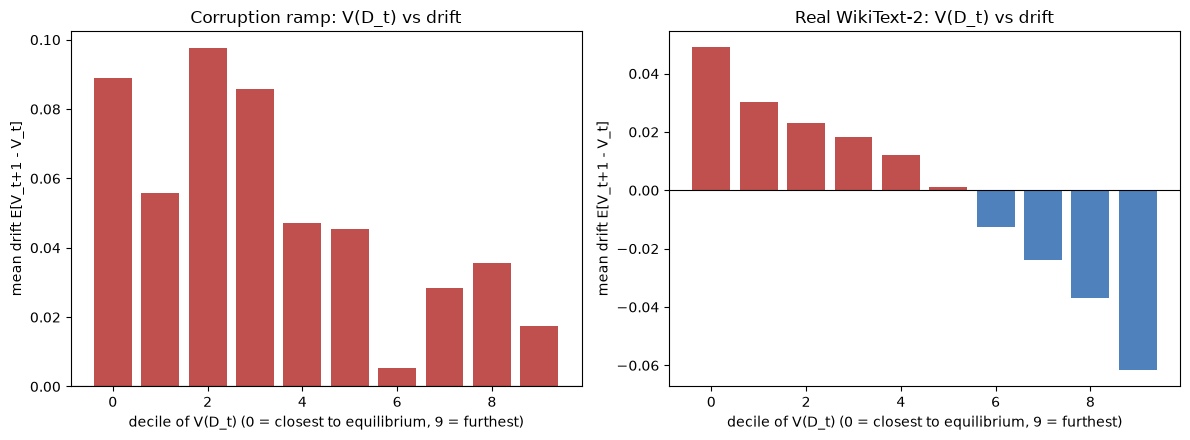

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, v_t, drift, title in [
    (axes[0], v_t_ramp, drift_ramp, "Corruption ramp: V(D_t) vs drift"),
    (axes[1], v_t_llm, drift_llm, "Real WikiText-2: V(D_t) vs drift"),
]:
    deciles = np.quantile(v_t, np.linspace(0, 1, 11))
    bin_centers, bin_drifts = [], []
    for i in range(10):
        lo, hi = deciles[i], deciles[i + 1]
        mask = (v_t >= lo) & (v_t <= hi) if i == 9 else (v_t >= lo) & (v_t < hi)
        if mask.sum() > 0:
            bin_centers.append(v_t[mask].mean())
            bin_drifts.append(drift[mask].mean())
    ax.bar(range(len(bin_drifts)), bin_drifts, color=["#c0504d" if d > 0 else "#4f81bd" for d in bin_drifts])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("decile of V(D_t) (0 = closest to equilibrium, 9 = furthest)")
    ax.set_ylabel("mean drift E[V_t+1 - V_t]")

plt.tight_layout()
plt.show()


## 5. Honest summary

**Corruption ramp**: the decrease condition fails clearly and consistently - mean drift is positive across essentially every decile of `V(D_t)`. This is the *correctly diagnosed* outcome, not a flaw: corruption severity is actively, monotonically forced upward by construction, pushing the reliability EMA away from its `V=0` equilibrium with no counteracting force the tracker could possibly detect. This also confirms the empirical check has real discriminative power - it correctly flags genuine, injected instability when it is actually present.

**Real WikiText-2 sequences**: the aggregate mean drift is close to zero - consistent with a bounded, roughly stationary process rather than one either compounding away from or converging cleanly toward equilibrium. Individual transitions do *not* satisfy the decrease condition reliably (dominated by token-level noise - fraction non-increasing is close to a coin flip), but the conditional structure the drift condition is actually stated in terms of shows real mean reversion in the furthest-from-equilibrium decile: states with unusually low reliability tend to move back toward equilibrium on average, while states already near equilibrium show a mild opposite drift (largely a floor effect near `V=0`, not evidence of instability).

Both results, and item 3's near-chance trend-vs-future-correctness finding above, are written up honestly in `DESIGN.md` §19 and `STUDY_PLAN.md` §3.6 - real, checked, sometimes weak or negative findings, not adjusted to look better than what the data actually shows. See `tests/test_temporal.py` for the exact, regression-tested assertions this notebook's numbers correspond to.
